# Customer Churn Prediction Using Machine Learning

## End-to-End Machine Learning Project

This project explores customer churn prediction using machine learning techniques and business analytics.

Multiple machine learning models were developed and evaluated to identify customers at risk of churn and uncover the major drivers influencing customer retention behavior.

## Objective
    
The goal of this project is to analyze customer behavior and build machine learning models capable of predicting customer churn.

## Business Problem
Customer churn negatively affects revenue and customer lifetime value. Predicting churn helps organizations improve retention strategies.

In [228]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

# Optional settings
pd.set_option('display.max_columns', None)

# Ignore warnings
import warnings
warnings.filterwarnings('ignore')

# Data Loading

In this phase, we load the dataset and inspect its structure to understand the available features and target variable.

In [2]:
df = pd.read_csv(
    r"C:\Users\ADMIN\Dropbox\Deep Learning\TelcoCustomerChurn\Telco-Customer-Churn.csv"
)

# Dataset Inspection

We inspect:
- shape of the dataset
- data types
- missing values
- duplicate records

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
df.shape

(7043, 21)

In [6]:
df.columns

Index(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport',
       'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling',
       'PaymentMethod', 'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [7]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [8]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


# Statistical Summary Observations

The dataset contains 7,043 customer records with several numerical variables.

## Key Observations

- The average customer tenure is approximately 32 months.
- Monthly charges range from 18.25 to 118.75.
- Approximately 16% of customers are senior citizens.
- Customer tenure varies significantly, indicating both new and long-term customers exist in the dataset.

These features may play an important role in predicting customer churn behavior.

In [9]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

# Missing Values Analysis

The dataset contains no missing values across all features.

This indicates that the dataset is relatively clean and suitable for further exploratory data analysis and machine learning preprocessing without requiring missing value imputation.

In [10]:
df.duplicated().sum()

np.int64(0)

# Duplicate Record Analysis

The dataset contains no duplicate rows.

This suggests that customer records are unique and no duplicate removal preprocessing is required.

In [11]:
df['Churn'].value_counts()

Churn
No     5174
Yes    1869
Name: count, dtype: int64

In [12]:
df.sample(5)

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
6066,5349-IECLD,Male,0,No,No,2,Yes,No,Fiber optic,No,No,Yes,No,Yes,Yes,Month-to-month,No,Electronic check,94.95,178.1,Yes
407,0111-KLBQG,Male,1,Yes,Yes,32,Yes,No,Fiber optic,No,Yes,No,No,Yes,Yes,Month-to-month,Yes,Mailed check,93.95,2861.45,No
6678,3978-YNKDD,Male,0,No,Yes,19,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Credit card (automatic),20.85,467.5,No
3455,7274-RTAPZ,Male,0,No,No,1,Yes,No,Fiber optic,No,No,No,No,Yes,Yes,Month-to-month,Yes,Electronic check,90.55,90.55,Yes
4609,2519-TWKFS,Male,0,Yes,Yes,25,Yes,Yes,DSL,No,No,No,Yes,No,No,One year,Yes,Mailed check,55.10,1466.1,No


# Random Sample Observations

A random inspection of customer records reveals that the dataset contains multiple categorical service-related features such as internet service type, online security, and device protection.

Some features contain categories such as "No internet service", which represent meaningful business categories rather than missing values.

Most features are categorical and will require encoding before machine learning model training.

# Exploratory Data Analysis

EDA helps identify:
- customer behavior patterns
- churn trends
- feature relationships
- potential predictors of churn

In [13]:
df['Churn'].value_counts(normalize=True) * 100

Churn
No     73.463013
Yes    26.536987
Name: proportion, dtype: float64

# Churn Distribution Analysis

The target variable shows that approximately:

- 73.46% of customers did not churn
- 26.54% of customers churned

This indicates that the dataset is moderately imbalanced.

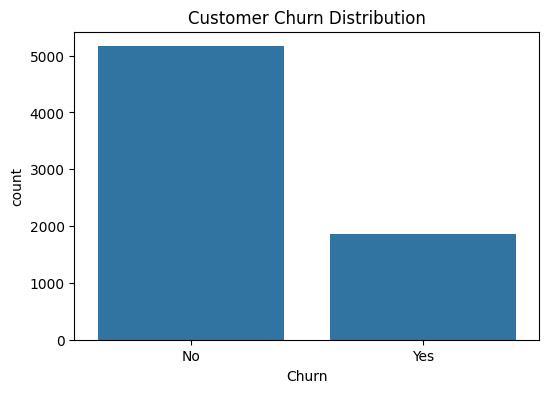

<Figure size 640x480 with 0 Axes>

In [229]:
plt.figure(figsize=(6,4))

sns.countplot(x='Churn', data=df)

plt.title('Customer Churn Distribution')

plt.show()

plt.savefig('Customer_Churn_Distribution.png', dpi=300, bbox_inches='tight')

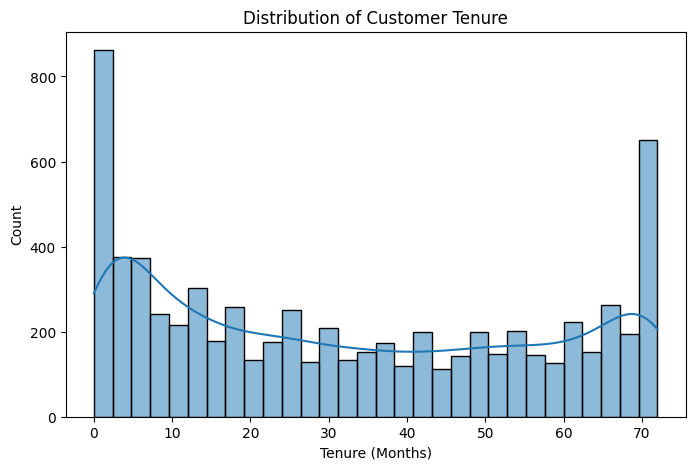

In [15]:
#Distribution of Tenure

plt.figure(figsize=(8,5))

sns.histplot(df['tenure'], bins=30, kde=True)

plt.title('Distribution of Customer Tenure')

plt.xlabel('Tenure (Months)')

plt.ylabel('Count')

plt.show()

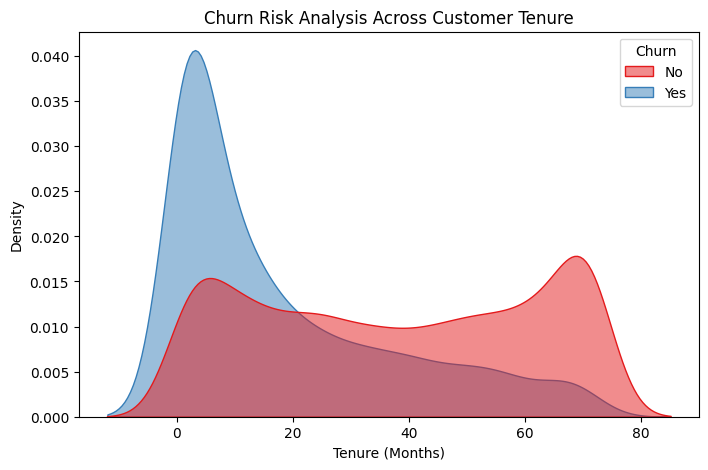

In [99]:
plt.figure(figsize=(8, 5))

sns.kdeplot(data=df, x='tenure', hue='Churn', fill=True, common_norm=False, palette='Set1', alpha=0.5)

plt.title('Churn Risk Analysis Across Customer Tenure')
plt.xlabel('Tenure (Months)')
plt.ylabel('Density')
plt.show()

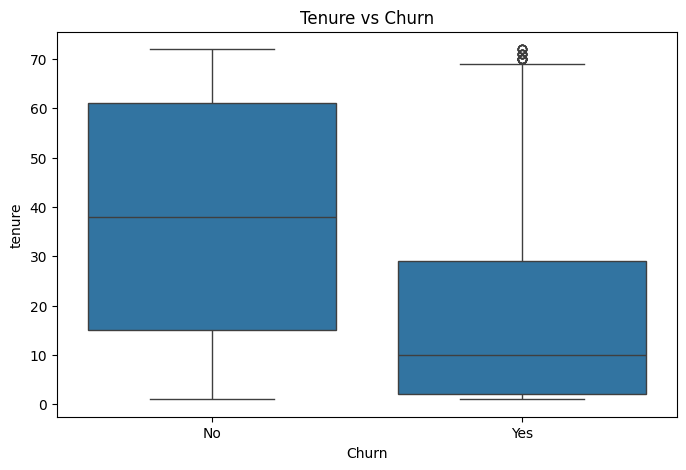

In [100]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='tenure', data=df)

plt.title('Tenure vs Churn')

plt.show()

### Observation

Customers who churn appear to have significantly lower tenure compared to customers who remain with the company.

This suggests that newer customers are more likely to leave, while long-term customers tend to remain loyal.

Customer tenure may therefore be an important predictor of churn.

# Monthly Charges Analysis

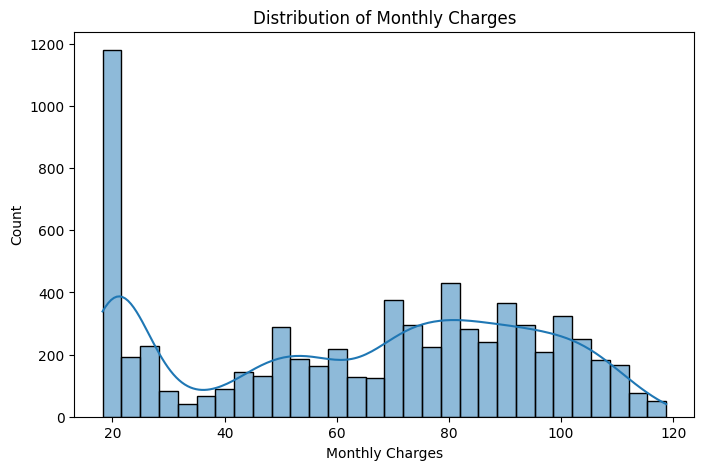

In [101]:
plt.figure(figsize=(8,5))

sns.histplot(df['MonthlyCharges'], bins=30, kde=True)

plt.title('Distribution of Monthly Charges')

plt.xlabel('Monthly Charges')

plt.ylabel('Count')

plt.show()

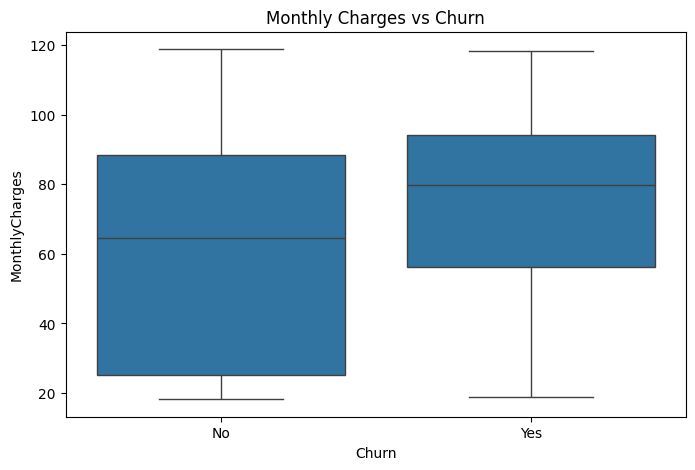

In [102]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='MonthlyCharges', data=df)

plt.title('Monthly Charges vs Churn')

plt.show()

In [103]:
df.groupby('Churn')['MonthlyCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,61.307408,31.094557,18.25,25.10,64.45,88.475,118.75
Yes,1869.0,74.441332,24.666053,18.85,56.15,79.65,94.200,118.35


### Observation

Customers who churn tend to have higher monthly charges compared to customers who remain.

This may indicate that customers with expensive service plans are more likely to discontinue services, possibly due to pricing concerns or perceived value dissatisfaction.

Monthly charges may therefore be an important predictor of customer churn.

In [104]:
df['TotalCharges'].dtype

dtype('float64')

In [105]:
df['TotalCharges'] = pd.to_numeric(
    df['TotalCharges'],
    errors='coerce'
)

In [106]:
df['TotalCharges'].isnull().sum()

np.int64(0)

In [107]:
df[df['TotalCharges'].isnull()]

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn


In [108]:
df.dropna(inplace=True)

In [109]:
df['TotalCharges'].isnull().sum()

np.int64(0)

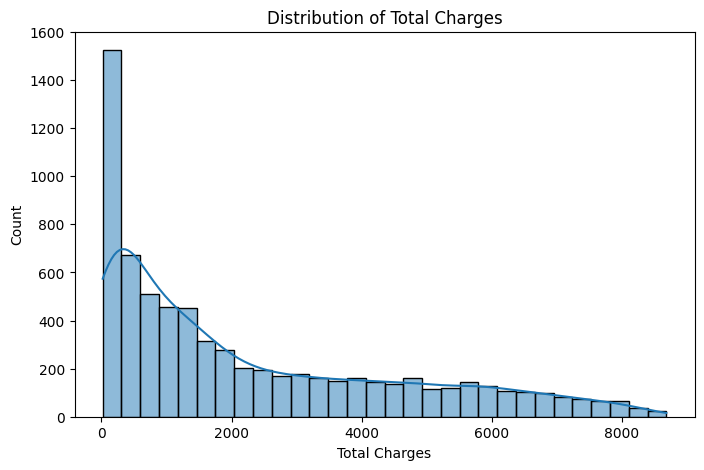

In [110]:
plt.figure(figsize=(8,5))

sns.histplot(df['TotalCharges'], bins=30, kde=True)

plt.title('Distribution of Total Charges')

plt.xlabel('Total Charges')

plt.ylabel('Count')

plt.show()

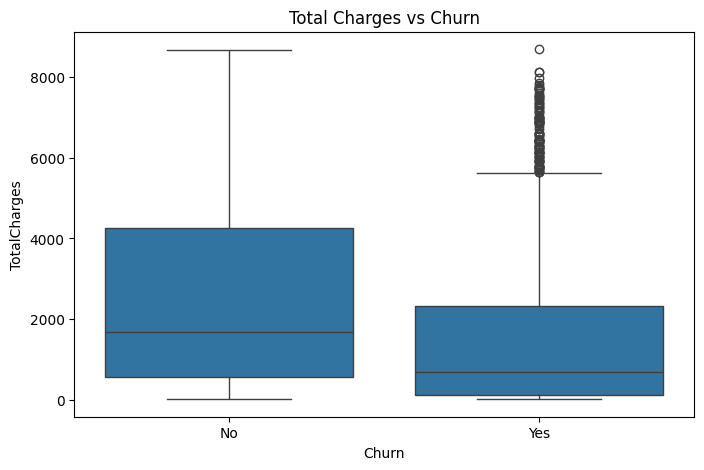

In [111]:
plt.figure(figsize=(8,5))

sns.boxplot(x='Churn', y='TotalCharges', data=df)

plt.title('Total Charges vs Churn')

plt.show()

# Total Charges Data Cleaning

The `TotalCharges` feature was initially stored as an object data type due to the presence of blank spaces in some records.

The column was converted to numeric format using `pd.to_numeric()` with `errors='coerce'`, which transformed invalid entries into missing values (`NaN`).

A small number of missing records were identified and removed because they represented customers with no recorded total charges.

In [112]:
df.groupby('Churn')['TotalCharges'].describe()

,count,mean,std,min,25%,50%,75%,max
Churn,,,,,,,,
No,5163.0,2555.344141,2329.456984,18.80,577.825,1683.60,4264.125,8672.45
Yes,1869.0,1531.796094,1890.822994,18.85,134.500,703.55,2331.300,8684.80


### Observation

Customers who churn generally exhibit lower total charges compared to customers who remain with the company.

This is likely because churned customers tend to have shorter tenure and therefore accumulate lower overall spending over time.

Total charges may therefore indirectly reflect customer loyalty and long-term engagement.

## Contract Type Analysis

Contract type describes the agreement duration between the customer and the company.

This analysis investigates whether customers with different contract types exhibit different churn behaviors.

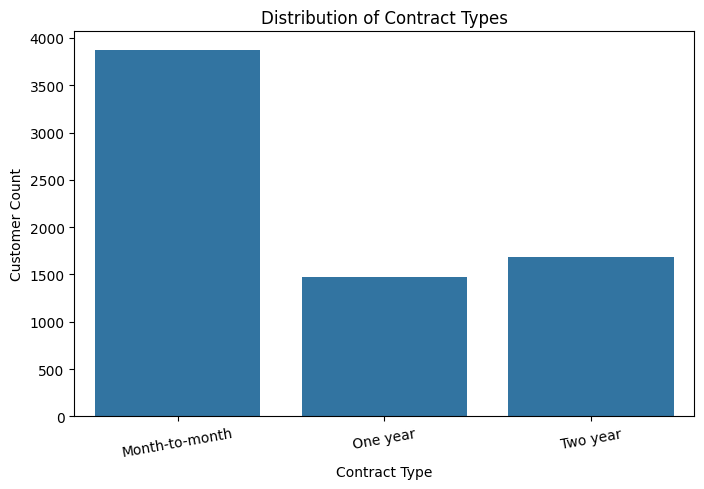

In [113]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', data=df)

plt.title('Distribution of Contract Types')

plt.xlabel('Contract Type')

plt.ylabel('Customer Count')

plt.xticks(rotation=10)

plt.show()

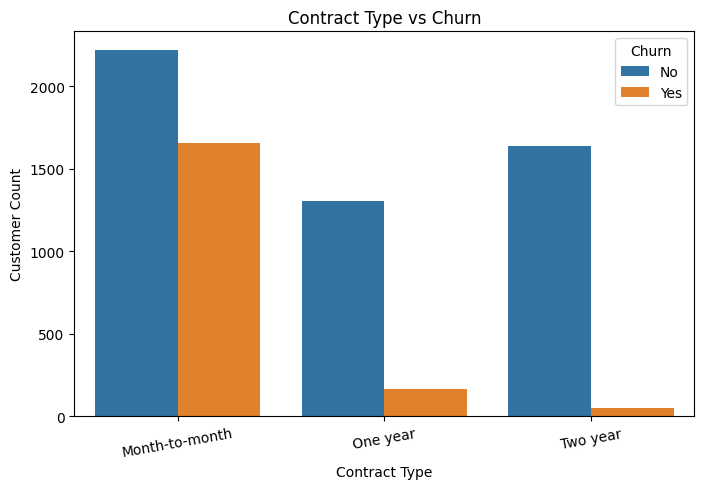

In [114]:
plt.figure(figsize=(8,5))

sns.countplot(x='Contract', hue='Churn', data=df)

plt.title('Contract Type vs Churn')

plt.xlabel('Contract Type')

plt.ylabel('Customer Count')

plt.xticks(rotation=10)

plt.show()

In [115]:
contract_churn = pd.crosstab(
    df['Contract'],
    df['Churn'],
    normalize='index'
) * 100

contract_churn

Churn,No,Yes
Contract,,
Month-to-month,57.290323,42.709677
One year,88.722826,11.277174
Two year,97.151335,2.848665


### Observation

Customers with month-to-month contracts appear significantly more likely to churn compared to customers with one-year or two-year contracts.

Customers on longer-term contracts demonstrate stronger retention and lower churn rates.

This suggests that contract commitment duration plays a major role in customer retention and loyalty.

### Business Insight

The company may reduce churn by encouraging customers to transition from month-to-month contracts to longer-term subscription plans through discounts, loyalty incentives, or bundled services.

# Internet Service Analysis

This analysis explores the relationship between internet service type and customer churn behavior.

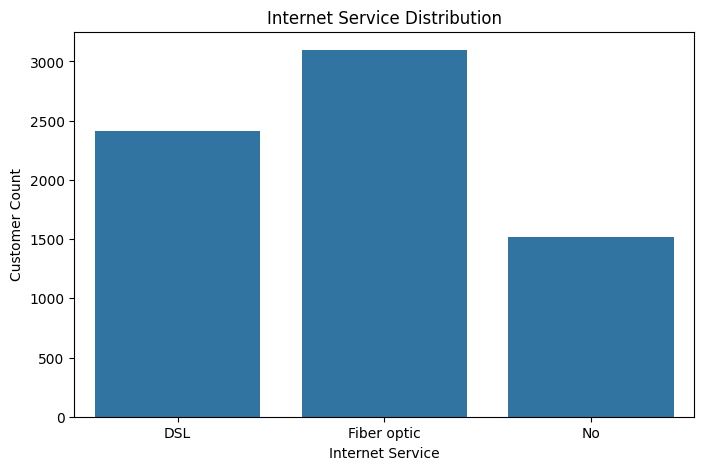

In [116]:
plt.figure(figsize=(8,5))

sns.countplot(x='InternetService', data=df)

plt.title('Internet Service Distribution')

plt.xlabel('Internet Service')

plt.ylabel('Customer Count')

plt.show()

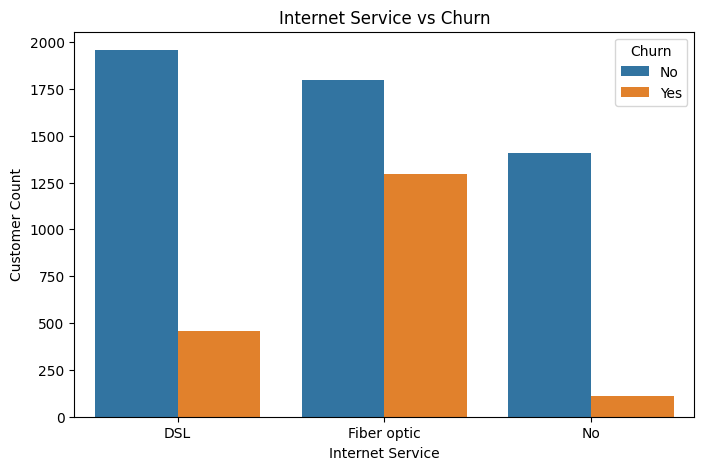

In [117]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='InternetService',
    hue='Churn',
    data=df
)

plt.title('Internet Service vs Churn')

plt.xlabel('Internet Service')

plt.ylabel('Customer Count')

plt.show()

In [118]:
internet_churn = pd.crosstab(
    df['InternetService'],
    df['Churn'],
    normalize='index'
) * 100

internet_churn

Churn,No,Yes
InternetService,,
DSL,81.001656,18.998344
Fiber optic,58.107235,41.892765
No,92.565789,7.434211


### Observation

Customers using fiber optic internet services appear to exhibit higher churn rates compared to customers using DSL or no internet service.

This may indicate issues related to pricing, service expectations, competition, or customer satisfaction among fiber optic users.

### Business Insight

The company may need to investigate customer satisfaction, pricing strategies, and service quality among fiber optic customers to improve retention.

# Payment Method Analysis

Payment method describes how customers pay for company services.

This analysis investigates whether customer payment behavior influences churn patterns.

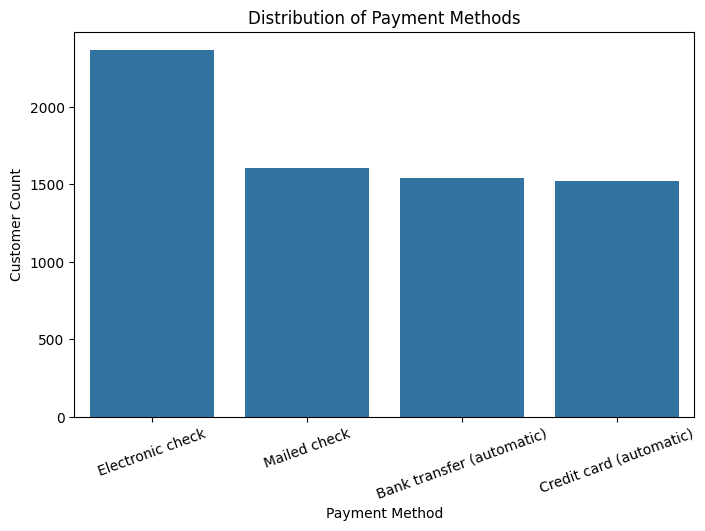

In [119]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='PaymentMethod',
    data=df
)

plt.title('Distribution of Payment Methods')

plt.xlabel('Payment Method')

plt.ylabel('Customer Count')

plt.xticks(rotation=20)

plt.show()

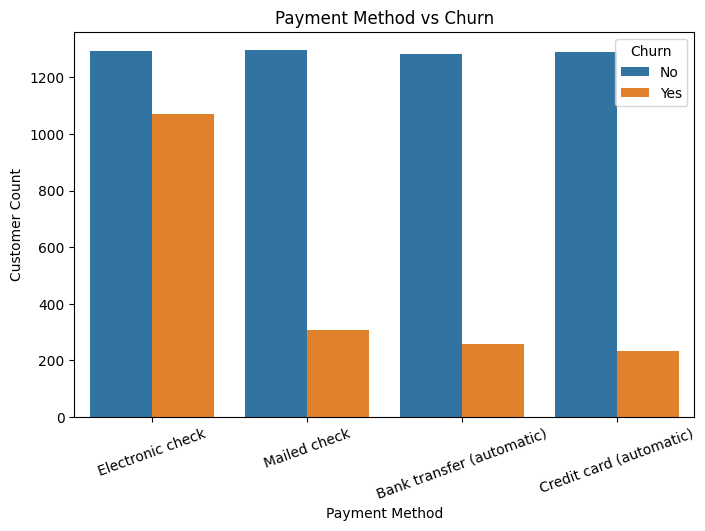

In [120]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='PaymentMethod',
    hue='Churn',
    data=df
)

plt.title('Payment Method vs Churn')

plt.xlabel('Payment Method')

plt.ylabel('Customer Count')

plt.xticks(rotation=20)

plt.show()

In [121]:
payment_churn = pd.crosstab(
    df['PaymentMethod'],
    df['Churn'],
    normalize='index'
) * 100

payment_churn

Churn,No,Yes
PaymentMethod,,
Bank transfer (automatic),83.268482,16.731518
Credit card (automatic),84.746877,15.253123
Electronic check,54.714588,45.285412
Mailed check,80.798005,19.201995


### Observation

Customers using electronic check payment methods appear to exhibit higher churn rates compared to customers using automatic payment methods such as bank transfers or credit cards.

This may suggest that customers using automated recurring payment systems demonstrate stronger retention and long-term engagement.

### Business Insight

Encouraging customers to adopt automatic payment methods may help improve customer retention by increasing convenience and reducing payment friction.

# Paperless Billing Analysis

This analysis investigates whether paperless billing adoption is associated with customer churn behavior.

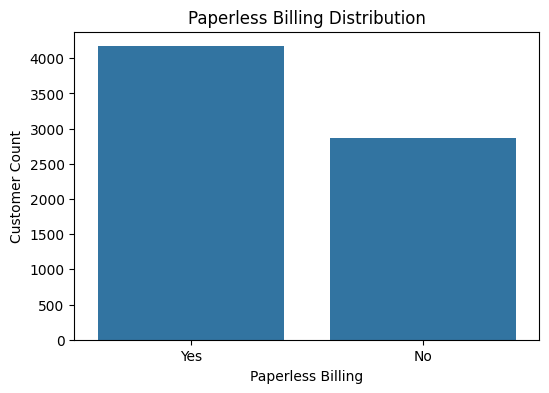

In [122]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='PaperlessBilling',
    data=df
)

plt.title('Paperless Billing Distribution')

plt.xlabel('Paperless Billing')

plt.ylabel('Customer Count')

plt.show()

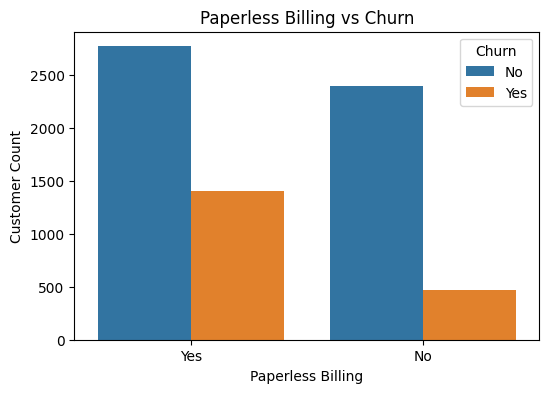

In [123]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='PaperlessBilling',
    hue='Churn',
    data=df
)

plt.title('Paperless Billing vs Churn')

plt.xlabel('Paperless Billing')

plt.ylabel('Customer Count')

plt.show()

In [124]:
paperless_churn = pd.crosstab(
    df['PaperlessBilling'],
    df['Churn'],
    normalize='index'
) * 100

paperless_churn

Churn,No,Yes
PaperlessBilling,,
No,83.624302,16.375698
Yes,66.410749,33.589251


### Observation

Customers using paperless billing appear to exhibit higher churn rates compared to customers who do not use paperless billing.

This may reflect behavioral differences among digitally engaged customers or customers using short-term service arrangements.

### Business Insight

Further investigation may be required to understand whether paperless billing customers experience different service expectations, pricing sensitivity, or customer engagement patterns.

# Online Security Analysis

This analysis investigates whether customers with online security services exhibit different churn behavior compared to customers without online security protection.

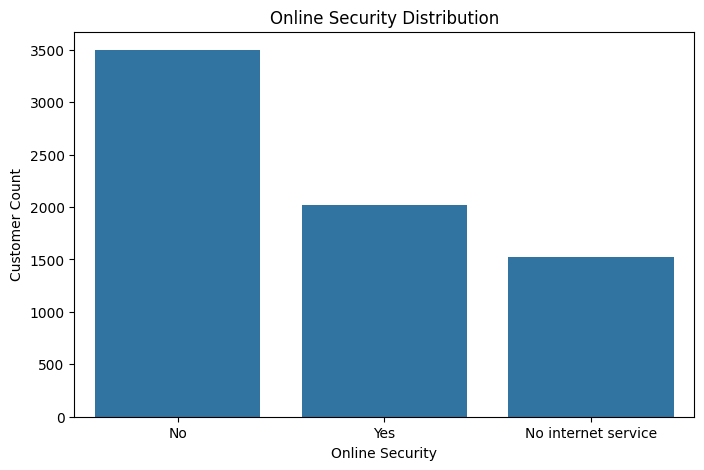

In [125]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='OnlineSecurity',
    data=df
)

plt.title('Online Security Distribution')

plt.xlabel('Online Security')

plt.ylabel('Customer Count')

plt.show()

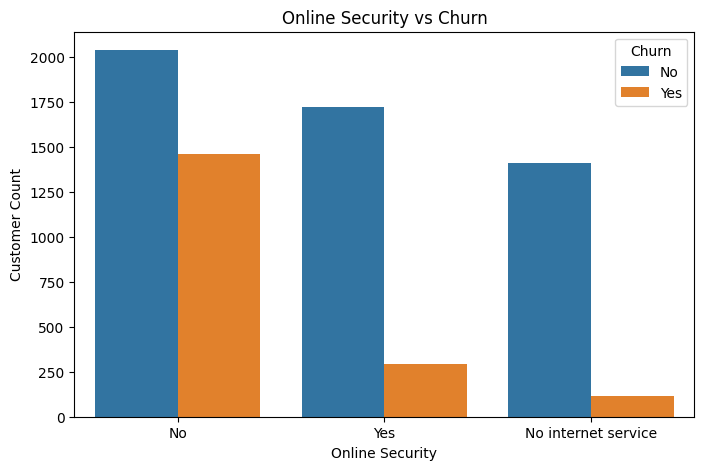

In [126]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='OnlineSecurity',
    hue='Churn',
    data=df
)

plt.title('Online Security vs Churn')

plt.xlabel('Online Security')

plt.ylabel('Customer Count')

plt.show()

In [127]:
online_security_churn = pd.crosstab(
    df['OnlineSecurity'],
    df['Churn'],
    normalize='index'
) * 100

online_security_churn

Churn,No,Yes
OnlineSecurity,,
No,58.221333,41.778667
No internet service,92.565789,7.434211
Yes,85.359801,14.640199


### Observation

Customers without online security services appear significantly more likely to churn compared to customers who subscribe to online security protection.

Customers with online security services demonstrate stronger retention and lower churn behavior.

### Business Insight

Online security services may increase customer retention by improving perceived service value and strengthening customer dependence on bundled services.

Promoting security-related services may therefore help reduce customer churn.

# Tech Support Analysis

This analysis examines whether access to technical support services influences customer churn behavior.

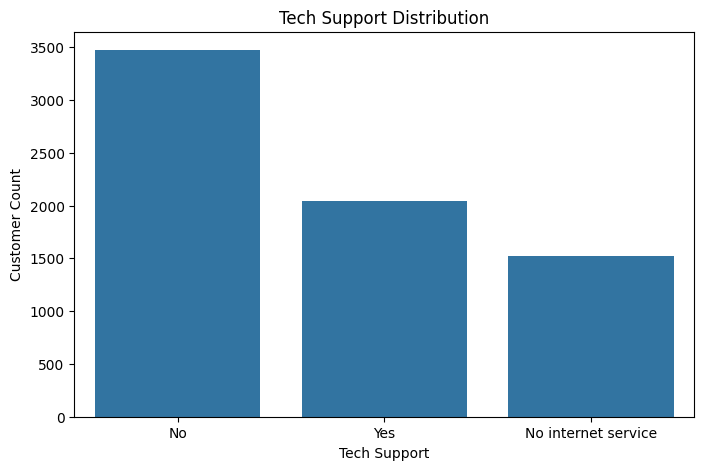

In [128]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='TechSupport',
    data=df
)

plt.title('Tech Support Distribution')

plt.xlabel('Tech Support')

plt.ylabel('Customer Count')

plt.show()

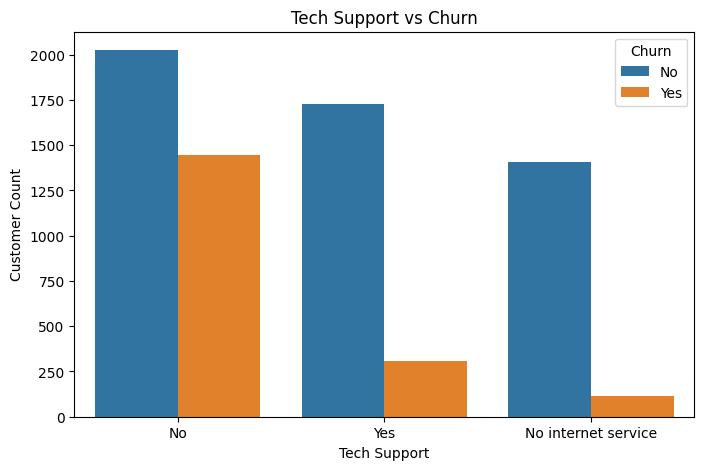

In [129]:
plt.figure(figsize=(8,5))

sns.countplot(
    x='TechSupport',
    hue='Churn',
    data=df
)

plt.title('Tech Support vs Churn')

plt.xlabel('Tech Support')

plt.ylabel('Customer Count')

plt.show()

In [130]:
techsupport_churn = pd.crosstab(
    df['TechSupport'],
    df['Churn'],
    normalize='index'
) * 100

techsupport_churn

Churn,No,Yes
TechSupport,,
No,58.352535,41.647465
No internet service,92.565789,7.434211
Yes,84.803922,15.196078


### Observation

Customers without technical support services appear more likely to churn compared to customers who receive technical support.

This suggests that customer support availability may contribute significantly to customer satisfaction and retention.

### Business Insight

Improving customer access to technical support services may strengthen customer relationships, improve satisfaction, and reduce churn risk.

# Senior Citizen Analysis

This analysis investigates whether senior citizens exhibit different churn behavior compared to non-senior customers.

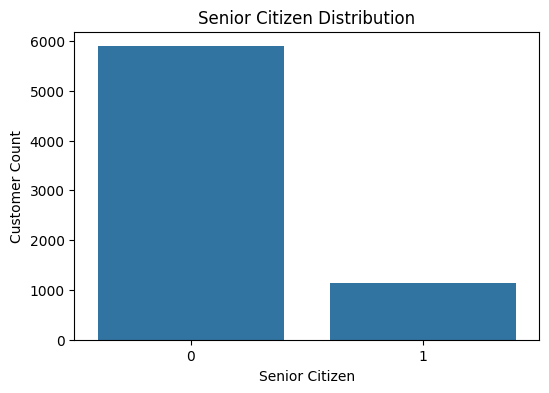

In [131]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='SeniorCitizen',
    data=df
)

plt.title('Senior Citizen Distribution')

plt.xlabel('Senior Citizen')

plt.ylabel('Customer Count')

plt.show()

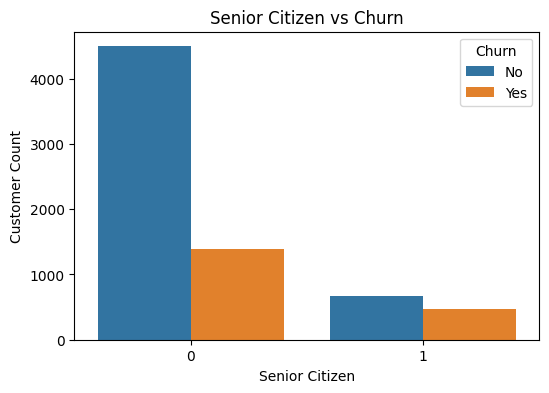

In [132]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='SeniorCitizen',
    hue='Churn',
    data=df
)

plt.title('Senior Citizen vs Churn')

plt.xlabel('Senior Citizen')

plt.ylabel('Customer Count')

plt.show()

In [133]:
senior_churn = pd.crosstab(
    df['SeniorCitizen'],
    df['Churn'],
    normalize='index'
) * 100

senior_churn

Churn,No,Yes
SeniorCitizen,,
0,76.349745,23.650255
1,58.318739,41.681261


### Observation

Senior citizens appear to exhibit higher churn rates compared to non-senior customers.

This may suggest that older customers experience different service expectations, affordability concerns, or customer support challenges.

### Business Insight

The company may improve retention among senior citizens through targeted support services, simplified customer experiences, and personalized retention programs.

# Partner Analysis

This analysis examines whether customers with partners exhibit different churn behavior compared to customers without partners.

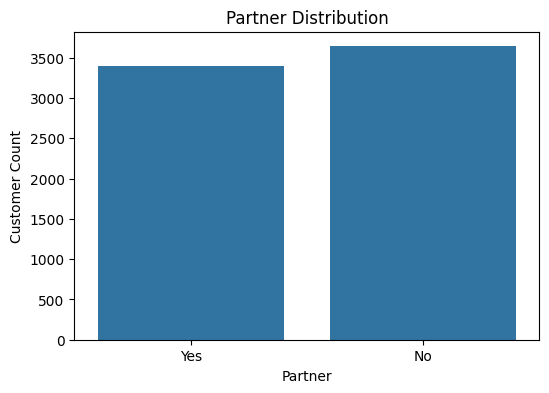

In [134]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Partner',
    data=df
)

plt.title('Partner Distribution')

plt.xlabel('Partner')

plt.ylabel('Customer Count')

plt.show()

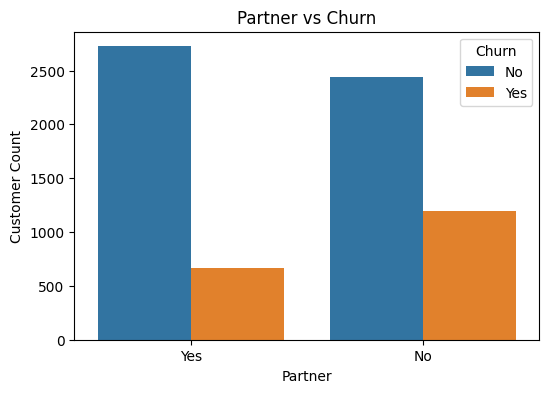

In [135]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Partner',
    hue='Churn',
    data=df
)

plt.title('Partner vs Churn')

plt.xlabel('Partner')

plt.ylabel('Customer Count')

plt.show()

In [136]:
partner_churn = pd.crosstab(
    df['Partner'],
    df['Churn'],
    normalize='index'
) * 100

partner_churn

Churn,No,Yes
Partner,,
No,67.023908,32.976092
Yes,80.282935,19.717065


### Observation

Customers with partners appear less likely to churn compared to customers without partners.

This may indicate that household stability and shared service usage contribute to stronger customer retention.

### Business Insight

Customers without partners may require targeted engagement strategies and retention campaigns to improve long-term customer loyalty.

# Dependents Analysis

This analysis investigates whether customers with dependents demonstrate different churn behavior compared to customers without dependents.

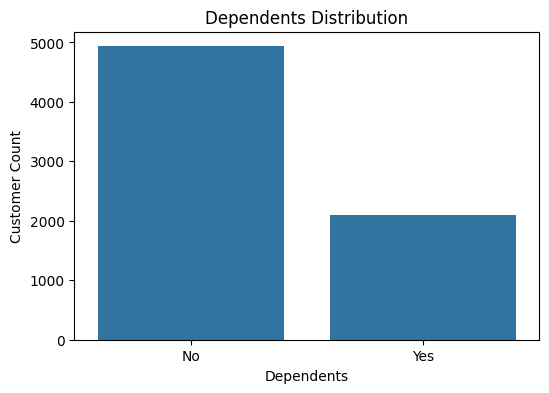

In [137]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Dependents',
    data=df
)

plt.title('Dependents Distribution')

plt.xlabel('Dependents')

plt.ylabel('Customer Count')

plt.show()

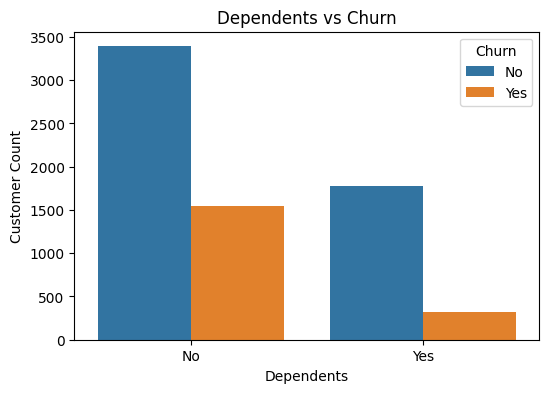

In [138]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='Dependents',
    hue='Churn',
    data=df
)

plt.title('Dependents vs Churn')

plt.xlabel('Dependents')

plt.ylabel('Customer Count')

plt.show()

In [139]:
dependents_churn = pd.crosstab(
    df['Dependents'],
    df['Churn'],
    normalize='index'
) * 100

dependents_churn

Churn,No,Yes
Dependents,,
No,68.720860,31.279140
Yes,84.468795,15.531205


### Observation

Customers with dependents appear less likely to churn compared to customers without dependents.

This suggests that customers with family-related responsibilities may demonstrate stronger long-term service commitment.

### Business Insight

Retention strategies may be improved by offering family-oriented packages and bundled household services that strengthen long-term customer relationships.

# Correlation and Feature Relationship Analysis

Correlation analysis helps identify relationships between features and the target variable.

Understanding feature relationships is important for:
- identifying strong churn predictors,
- detecting redundant variables,
- and improving machine learning model interpretation.

In [140]:
df_encoded = df.copy()

In [141]:
from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

for column in df_encoded.columns:
    if df_encoded[column].dtype == 'object':
        df_encoded[column] = le.fit_transform(df_encoded[column])

In [142]:
correlation_matrix = df_encoded.corr()

correlation_matrix

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
customerID,1.000000,0.006235,-0.002368,-0.026509,-0.011871,0.007209,-0.006987,0.004497,-0.012335,0.013740,-0.002960,-0.006726,0.001763,-0.007650,-0.017207,0.015949,-0.002225,0.011754,-0.004445,-0.000263,-0.017858
gender,0.006235,1.000000,-0.001819,-0.001379,0.010349,0.005285,-0.007515,-0.006908,-0.002236,-0.014899,-0.011920,0.001348,-0.006695,-0.005624,-0.008920,0.000095,-0.011902,0.016942,-0.013779,0.000048,-0.008545
SeniorCitizen,-0.002368,-0.001819,1.000000,0.016957,-0.210550,0.015683,0.008392,0.146287,-0.032160,-0.127937,-0.013355,-0.021124,-0.151007,0.031019,0.047088,-0.141820,0.156258,-0.038158,0.219874,0.102411,0.150541
Partner,-0.026509,-0.001379,0.016957,1.000000,0.452269,0.381912,0.018397,0.142717,0.000513,0.150610,0.153045,0.165614,0.126488,0.136679,0.129907,0.294094,-0.013957,-0.156232,0.097825,0.319072,-0.149982
Dependents,-0.011871,0.010349,-0.210550,0.452269,1.000000,0.163386,-0.001078,-0.024975,0.044030,0.151198,0.090231,0.079723,0.132530,0.046214,0.022088,0.240556,-0.110131,-0.041989,-0.112343,0.064653,-0.163128
tenure,0.007209,0.005285,0.015683,0.381912,0.163386,1.000000,0.007877,0.343673,-0.029835,0.327283,0.372434,0.372669,0.324729,0.290572,0.296785,0.676734,0.004823,-0.370087,0.246862,0.825880,-0.354049
PhoneService,-0.006987,-0.007515,0.008392,0.018397,-0.001078,0.007877,1.000000,-0.020504,0.387266,-0.014163,0.024040,0.004718,-0.018136,0.056393,0.043025,0.003019,0.016696,-0.005499,0.248033,0.113008,0.011691
MultipleLines,0.004497,-0.006908,0.146287,0.142717,-0.024975,0.343673,-0.020504,1.000000,-0.108849,0.007306,0.117276,0.122614,0.010941,0.175403,0.181705,0.111029,0.165306,-0.176598,0.433905,0.453202,0.038043
InternetService,-0.012335,-0.002236,-0.032160,0.000513,0.044030,-0.029835,0.387266,-0.108849,1.000000,-0.028003,0.036735,0.045558,-0.025626,0.108190,0.097967,0.099579,-0.138166,0.084504,-0.322173,-0.175691,-0.047097
OnlineSecurity,0.013740,-0.014899,-0.127937,0.150610,0.151198,0.327283,-0.014163,0.007306,-0.028003,1.000000,0.184942,0.175789,0.284875,0.044399,0.056313,0.373980,-0.157723,-0.096593,-0.053576,0.254473,-0.289050


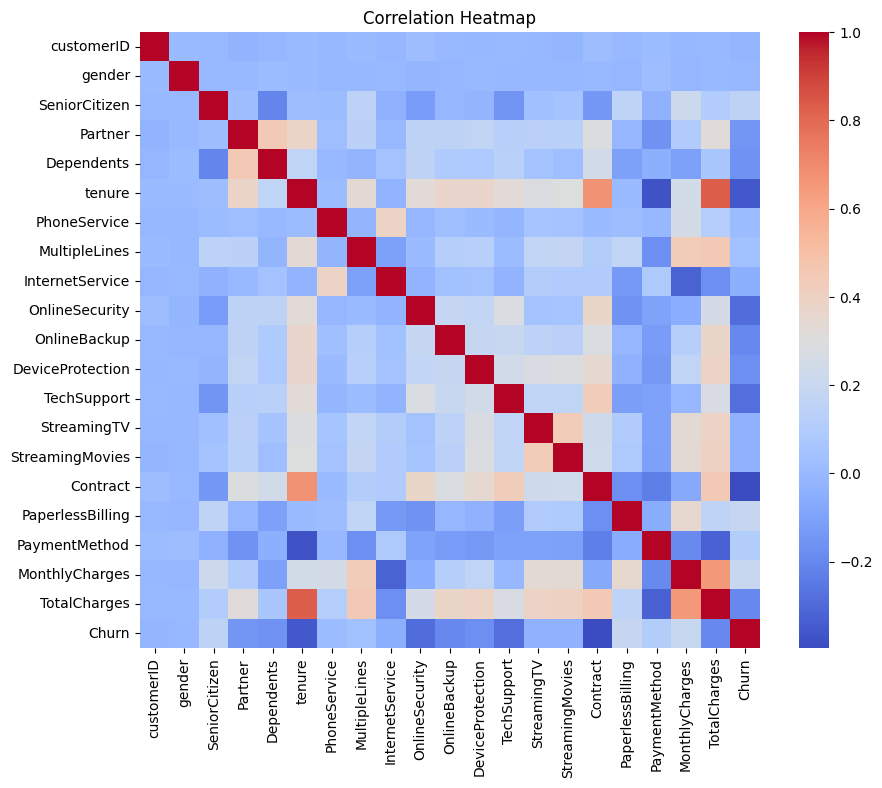

In [143]:
plt.figure(figsize=(10,8))

sns.heatmap(
    correlation_matrix,
    annot=False,
    cmap='coolwarm'
)

plt.title('Correlation Heatmap')

plt.show()

### Observation

The correlation matrix reveals several meaningful relationships between customer features.

Customer tenure demonstrates moderate positive relationships with service-related features such as online security, technical support, and multiple lines, suggesting that long-term customers are more likely to adopt additional services.

Service-related variables such as online security, online backup, device protection, and technical support also exhibit positive relationships with one another, indicating bundled service adoption behavior.

Most feature correlations are moderate rather than extremely high, suggesting limited multicollinearity and a relatively healthy feature structure for machine learning modeling.

In [144]:
churn_correlation = correlation_matrix['Churn'].sort_values(ascending=False)

churn_correlation

Churn               1.000000
MonthlyCharges      0.192858
PaperlessBilling    0.191454
SeniorCitizen       0.150541
PaymentMethod       0.107852
MultipleLines       0.038043
PhoneService        0.011691
gender             -0.008545
customerID         -0.017858
StreamingTV        -0.036303
StreamingMovies    -0.038802
InternetService    -0.047097
Partner            -0.149982
Dependents         -0.163128
DeviceProtection   -0.177883
OnlineBackup       -0.195290
TotalCharges       -0.199484
TechSupport        -0.282232
OnlineSecurity     -0.289050
tenure             -0.354049
Contract           -0.396150
Name: Churn, dtype: float64

### Observation

Several features demonstrate meaningful relationships with customer churn.

Contract type and customer tenure exhibit the strongest negative correlations with churn, indicating that long-term customers and customers on extended contracts are less likely to leave the company.

Service-related features such as online security and technical support also show strong negative relationships with churn, suggesting that customers using value-added services demonstrate stronger retention behavior.

Monthly charges exhibit a positive correlation with churn, indicating that customers with higher monthly costs may be more likely to discontinue services.

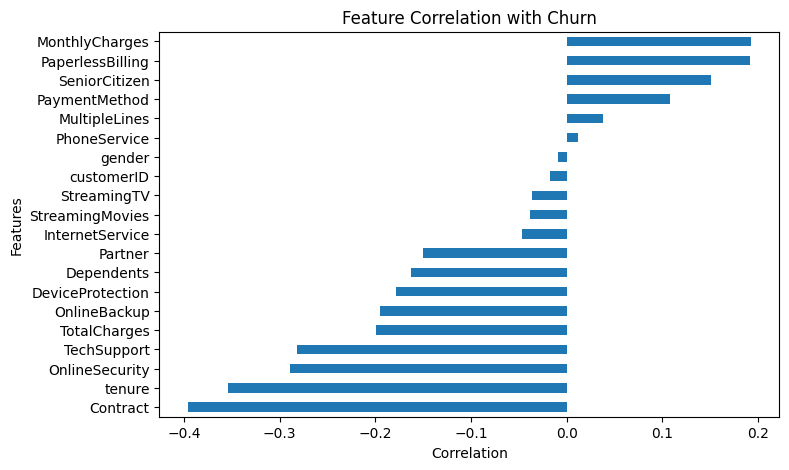

In [145]:
plt.figure(figsize=(8,5))

churn_correlation.drop('Churn').sort_values().plot(kind='barh')

plt.title('Feature Correlation with Churn')

plt.xlabel('Correlation')

plt.ylabel('Features')

plt.show()

### Observation

Several features demonstrate meaningful relationships with customer churn.

Contract type and customer tenure exhibit the strongest negative correlations with churn, indicating that long-term customers and customers on extended contracts are less likely to leave the company.

Service-related features such as online security and technical support also show strong negative relationships with churn, suggesting that customers using value-added services demonstrate stronger retention behavior.

Monthly charges exhibit a positive correlation with churn, indicating that customers with higher monthly costs may be more likely to discontinue services.

### Business Insight

Customer retention appears strongly influenced by customer engagement, contract commitment, and service adoption.

The company may reduce churn by:
- encouraging long-term contracts,
- improving onboarding for new customers,
- promoting technical support and security services,
- and evaluating pricing strategies for high monthly charge customers.

# Machine Learning Preparation

Before training machine learning models, the dataset must be prepared through preprocessing steps such as:
- removing unnecessary features,
- encoding categorical variables,
- splitting the dataset,
- and scaling numerical variables.

These preprocessing steps help improve model performance and ensure compatibility with machine learning algorithms.

In [146]:
df_ml = df.drop('customerID', axis=1)

In [147]:
df_ml['Churn'] = df_ml['Churn'].map({
    'Yes': 1,
    'No': 0
})

In [148]:
df_ml['Churn'].value_counts()

Churn
0    5163
1    1869
Name: count, dtype: int64

In [149]:
df_ml = pd.get_dummies(
    df_ml,
    drop_first=True
)

In [150]:
df_ml.head()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges,Churn,gender_Male,Partner_Yes,Dependents_Yes,PhoneService_Yes,MultipleLines_No phone service,MultipleLines_Yes,InternetService_Fiber optic,InternetService_No,OnlineSecurity_No internet service,OnlineSecurity_Yes,OnlineBackup_No internet service,OnlineBackup_Yes,DeviceProtection_No internet service,DeviceProtection_Yes,TechSupport_No internet service,TechSupport_Yes,StreamingTV_No internet service,StreamingTV_Yes,StreamingMovies_No internet service,StreamingMovies_Yes,Contract_One year,Contract_Two year,PaperlessBilling_Yes,PaymentMethod_Credit card (automatic),PaymentMethod_Electronic check,PaymentMethod_Mailed check
0,0,1,29.85,29.85,0,False,True,False,False,True,False,False,False,False,False,False,True,False,False,False,False,False,False,False,False,False,False,True,False,True,False
1,0,34,56.95,1889.50,0,True,False,False,True,False,False,False,False,False,True,False,False,False,True,False,False,False,False,False,False,True,False,False,False,False,True
2,0,2,53.85,108.15,1,True,False,False,True,False,False,False,False,False,True,False,True,False,False,False,False,False,False,False,False,False,False,True,False,False,True
3,0,45,42.30,1840.75,0,True,False,False,False,True,False,False,False,False,True,False,False,False,True,False,True,False,False,False,False,True,False,False,False,False,False
4,0,2,70.70,151.65,1,False,False,False,True,False,False,True,False,False,False,False,False,False,False,False,False,False,False,False,False,False,False,True,False,True,False


In [151]:
df_ml.shape

(7032, 31)

In [152]:
X = df_ml.drop('Churn', axis=1)

y = df_ml['Churn']

In [153]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [154]:
print("Training Features Shape:", X_train.shape)

print("Testing Features Shape:", X_test.shape)

print("Training Target Shape:", y_train.shape)

print("Testing Target Shape:", y_test.shape)

Training Features Shape: (5625, 30)
Testing Features Shape: (1407, 30)
Training Target Shape: (5625,)
Testing Target Shape: (1407,)


In [155]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

# Data Preprocessing Summary

Several preprocessing steps were performed before machine learning modeling:

- The `customerID` column was removed because it contained no predictive value.
- The target variable (`Churn`) was encoded into binary numeric values.
- Categorical variables were converted into numeric format using one-hot encoding.
- The dataset was divided into training and testing subsets.
- Numerical features were standardized using `StandardScaler`.

These preprocessing steps help improve model performance and ensure compatibility with machine learning algorithms.

# Logistic Regression Baseline Model

Logistic Regression is used as the baseline machine learning model for customer churn prediction.

This algorithm is widely used for binary classification problems because it is:
- simple,
- interpretable,
- computationally efficient,
- and effective for baseline performance evaluation.

In [156]:
from sklearn.linear_model import LogisticRegression

In [157]:
log_model = LogisticRegression(
    max_iter=1000
)

log_model.fit(
    X_train_scaled,
    y_train
)

LogisticRegression(max_iter=1000)

The Logistic Regression model was configured with an increased maximum iteration limit to ensure convergence during optimization due to the high dimensionality introduced by categorical feature encoding.

In [158]:
y_pred = log_model.predict(X_test_scaled)

In [159]:
y_prob = log_model.predict_proba(X_test_scaled)[:,1]

In [160]:
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [161]:
print("Accuracy:", accuracy_score(y_test, y_pred))

print("Precision:", precision_score(y_test, y_pred))

print("Recall:", recall_score(y_test, y_pred))

print("F1 Score:", f1_score(y_test, y_pred))

print("ROC-AUC:", roc_auc_score(y_test, y_prob))

Accuracy: 0.8038379530916845
Precision: 0.6475903614457831
Recall: 0.5748663101604278
F1 Score: 0.6090651558073654
ROC-AUC: 0.8356727976766699


### Logistic Regression Evaluation

The Logistic Regression model achieved an accuracy of approximately 80%, demonstrating strong baseline performance for customer churn prediction.

The model achieved a ROC-AUC score of 0.84, indicating strong capability in distinguishing between customers likely to churn and customers likely to remain.

Precision and recall scores suggest that the model is reasonably effective at identifying churn-risk customers, although some churn cases remain undetected.

### Business Insight

The machine learning model demonstrates that customer churn can be predicted with substantial accuracy using customer behavior, contract information, pricing patterns, and service adoption variables.

These predictive insights may help businesses proactively identify at-risk customers and implement targeted retention strategies before customer loss occurs.

In [162]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1033
           1       0.65      0.57      0.61       374

    accuracy                           0.80      1407
   macro avg       0.75      0.73      0.74      1407
weighted avg       0.80      0.80      0.80      1407



In [163]:
cm = confusion_matrix(y_test, y_pred)

cm

array([[916, 117],
       [159, 215]])

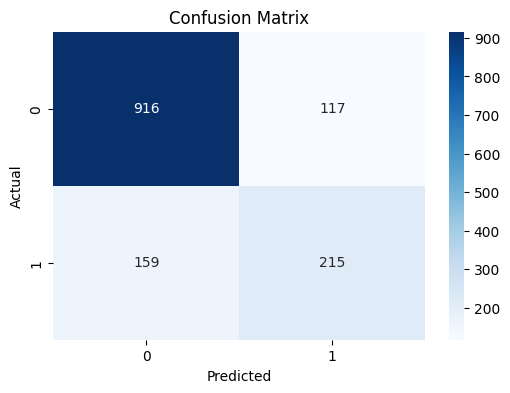

In [164]:
plt.figure(figsize=(6,4))

sns.heatmap(
    cm,
    annot=True,
    fmt='d',
    cmap='Blues'
)

plt.title('Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [165]:
train_accuracy = log_model.score(
    X_train_scaled,
    y_train
)

test_accuracy = log_model.score(
    X_test_scaled,
    y_test
)

print("Training Accuracy:", train_accuracy)

print("Testing Accuracy:", test_accuracy)

Training Accuracy: 0.8042666666666667
Testing Accuracy: 0.8038379530916845


## Logistic Regression Performance

The Logistic Regression model achieved strong baseline performance for customer churn prediction, with an accuracy of approximately 80% on both training and testing datasets.

The close similarity between training and testing accuracy indicates that the model generalizes well and does not exhibit significant overfitting.

Evaluation metrics such as precision, recall, F1-score, and ROC-AUC demonstrate that the model has good capability in distinguishing between customers likely to churn and customers likely to remain.

## Business Insight

The machine learning model demonstrates that customer churn can be predicted with substantial accuracy using customer behavior, contract information, pricing patterns, and service adoption variables.

The model may help businesses proactively identify customers at risk of churn and implement targeted retention strategies before customer loss occurs.

The strong generalization performance suggests that the predictive model may perform reliably on unseen customer data.

# Advanced Machine Learning Models

After establishing a Logistic Regression baseline model, more advanced machine learning algorithms are explored to improve predictive performance and capture complex nonlinear relationships within the customer churn dataset.

The following models are evaluated:
- Decision Tree Classifier
- Random Forest Classifier

# Decision Tree Classifier

A Decision Tree Classifier is a nonlinear machine learning algorithm that predicts outcomes by learning decision rules from the dataset.

Decision Trees are highly interpretable and can capture complex relationships between features and customer churn behavior.

In [166]:
from sklearn.tree import DecisionTreeClassifier

In [167]:
dt_model = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

In [168]:
dt_model.fit(
    X_train,
    y_train
)

DecisionTreeClassifier(max_depth=5, random_state=42)

In [201]:
dt_pred = dt_model.predict(X_test)

dt_prob = dt_model.predict_proba(X_test)[:,1]

In [170]:
print("Accuracy:", accuracy_score(y_test, dt_pred))

print("Precision:", precision_score(y_test, dt_pred))

print("Recall:", recall_score(y_test, dt_pred))

print("F1 Score:", f1_score(y_test, dt_pred))

print("ROC-AUC:", roc_auc_score(y_test, dt_prob))

Accuracy: 0.7782515991471215
Precision: 0.5807291666666666
Recall: 0.5962566844919787
F1 Score: 0.5883905013192612
ROC-AUC: 0.8195096572466881


## Decision Tree Performance

The Decision Tree model was able to capture nonlinear relationships within the customer churn dataset and achieved reasonable predictive performance.

Compared to Logistic Regression, the Decision Tree demonstrated slightly improved recall, indicating better capability in identifying customers likely to churn.

However, the model achieved slightly lower overall accuracy and ROC-AUC performance, suggesting that Logistic Regression remained more effective at overall customer classification.

## Business Insight

The Decision Tree model demonstrates the ability to identify customer churn risk through nonlinear decision patterns and hierarchical business rules.

Although overall predictive performance was slightly lower than Logistic Regression, the model showed improved churn detection capability, which may support proactive customer retention efforts.

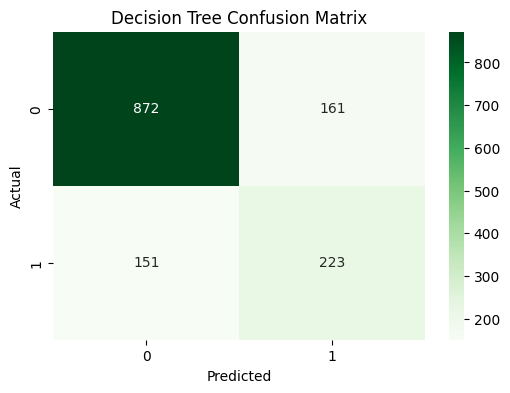

In [171]:
dt_cm = confusion_matrix(y_test, dt_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    dt_cm,
    annot=True,
    fmt='d',
    cmap='Greens'
)

plt.title('Decision Tree Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

## Business Insight

The Decision Tree model correctly identifies a majority of non-churning customers (TN = 872), but struggles moderately with identifying churners (TP = 223). The model produces a balanced number of false positives and false negatives, indicating no strong bias toward either class. However, the moderate recall suggests that a significant portion of churners are still missed.

In [172]:
dt_train_acc = dt_model.score(X_train, y_train)

dt_test_acc = dt_model.score(X_test, y_test)

print("Training Accuracy:", dt_train_acc)

print("Testing Accuracy:", dt_test_acc)

Training Accuracy: 0.8019555555555555
Testing Accuracy: 0.7782515991471215


## Decision Tree Performance

The Decision Tree model successfully captured nonlinear relationships within the customer churn dataset and achieved reasonable predictive performance.

The model demonstrated slightly improved recall compared to Logistic Regression, indicating better ability to identify customers likely to churn.

However, the model achieved lower overall accuracy and ROC-AUC performance and exhibited mild overfitting, as indicated by the difference between training and testing accuracy.

# Random Forest Classifier

Random Forest is an ensemble machine learning algorithm that combines multiple decision trees to improve prediction accuracy and reduce overfitting.

This model is widely used because of its strong predictive performance and ability to capture complex nonlinear relationships.

In [173]:
from sklearn.ensemble import RandomForestClassifier

In [174]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    max_depth=8,
    random_state=42
)

In [175]:
rf_model.fit(
    X_train,
    y_train
)

RandomForestClassifier(max_depth=8, random_state=42)

In [176]:
rf_pred = rf_model.predict(X_test)

rf_prob = rf_model.predict_proba(X_test)[:,1]

In [177]:
print("Accuracy:", accuracy_score(y_test, rf_pred))

print("Precision:", precision_score(y_test, rf_pred))

print("Recall:", recall_score(y_test, rf_pred))

print("F1 Score:", f1_score(y_test, rf_pred))

print("ROC-AUC:", roc_auc_score(y_test, rf_prob))

Accuracy: 0.7931769722814499
Precision: 0.6509090909090909
Recall: 0.4786096256684492
F1 Score: 0.551617873651772
ROC-AUC: 0.8369721645588624


## Random Forest Performance

The Random Forest model demonstrated strong predictive capability and achieved the highest ROC-AUC score among the evaluated models, indicating strong ability to distinguish between customers likely to churn and customers likely to remain.

The model also achieved the highest precision, suggesting improved reliability when predicting churn-risk customers.

However, recall performance declined compared to Logistic Regression and Decision Tree models, indicating that some churn cases remained undetected.

## Business Insight

The Random Forest model demonstrates strong capability in identifying high-confidence churn-risk customers while minimizing false churn predictions.

Although the model missed some churning customers, its strong precision and ROC-AUC performance suggest potential value in targeted customer retention campaigns and churn risk prioritization strategies.

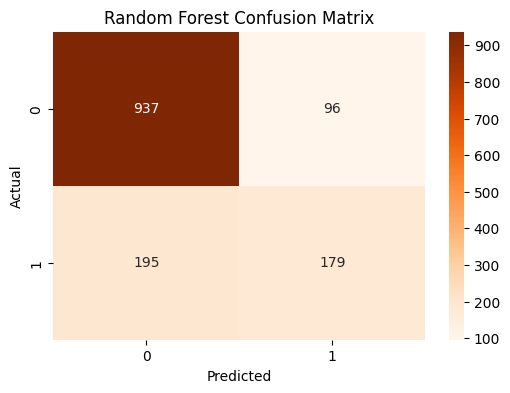

In [178]:
rf_cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    rf_cm,
    annot=True,
    fmt='d',
    cmap='Oranges'
)

plt.title('Random Forest Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [179]:
rf_train_acc = rf_model.score(X_train, y_train)

rf_test_acc = rf_model.score(X_test, y_test)

print("Training Accuracy:", rf_train_acc)

print("Testing Accuracy:", rf_test_acc)

Training Accuracy: 0.8312888888888889
Testing Accuracy: 0.7931769722814499


In [180]:
model_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred)
    ],
    
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred)
    ],
    
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob)
    ]
})

model_results

,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803838,0.574866,0.609065,0.835673
1,Decision Tree,0.778252,0.596257,0.588391,0.819510
2,Random Forest,0.793177,0.478610,0.551618,0.836972


# Model Comparison Summary

Three machine learning models were evaluated for customer churn prediction:
- Logistic Regression
- Decision Tree Classifier
- Random Forest Classifier

The Logistic Regression model achieved the strongest overall balance between accuracy, recall, F1-score, and generalization performance, making it the most reliable baseline model for customer churn prediction.

The Decision Tree model demonstrated slightly improved recall, indicating better capability in identifying customers likely to churn, although it exhibited lower overall predictive performance and mild overfitting.

The Random Forest model achieved the highest ROC-AUC score, demonstrating strong capability in distinguishing between churning and non-churning customers. However, the model showed lower recall performance and moderate overfitting, indicating a more conservative prediction behavior.

# Final Business Insight

The analysis demonstrates that customer churn can be effectively predicted using machine learning techniques and customer behavioral data.

Variables such as contract type, customer tenure, pricing structure, and service adoption emerged as important indicators of customer retention behavior.

Among the evaluated models, Logistic Regression provided the most balanced predictive performance and strongest generalization capability, suggesting strong potential for supporting proactive customer retention strategies and churn risk monitoring systems.

### Key Observation

Logistic Regression demonstrated the most balanced predictive performance overall, while Random Forest achieved the strongest probability discrimination capability through ROC-AUC performance.

# XGBoost Classifier

XGBoost (Extreme Gradient Boosting) is an advanced ensemble machine learning algorithm designed to improve predictive performance through sequential learning and error correction.

XGBoost is widely used in predictive analytics because of its strong accuracy, scalability, and ability to capture complex nonlinear relationships.

In [182]:
from xgboost import XGBClassifier

In [183]:
xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    random_state=42,
    eval_metric='logloss'
)

In [184]:
xgb_model.fit(
    X_train,
    y_train
)

XGBClassifier(base_score=None, booster=None, callbacks=None,
              colsample_bylevel=None, colsample_bynode=None,
              colsample_bytree=None, device=None, early_stopping_rounds=None,
              enable_categorical=False, eval_metric='logloss',
              feature_types=None, feature_weights=None, gamma=None,
              grow_policy=None, importance_type=None,
              interaction_constraints=None, learning_rate=0.1, max_bin=None,
              max_cat_threshold=None, max_cat_to_onehot=None,
              max_delta_step=None, max_depth=4, max_leaves=None,
              min_child_weight=None, missing=nan, monotone_constraints=None,
              multi_strategy=None, n_estimators=100, n_jobs=None,
              num_parallel_tree=None, ...)

In [185]:
xgb_pred = xgb_model.predict(X_test)

xgb_prob = xgb_model.predict_proba(X_test)[:,1]

In [186]:
print("Accuracy:", accuracy_score(y_test, xgb_pred))

print("Precision:", precision_score(y_test, xgb_pred))

print("Recall:", recall_score(y_test, xgb_pred))

print("F1 Score:", f1_score(y_test, xgb_pred))

print("ROC-AUC:", roc_auc_score(y_test, xgb_prob))

Accuracy: 0.7917555081734187
Precision: 0.6261682242990654
Recall: 0.5374331550802139
F1 Score: 0.5784172661870504
ROC-AUC: 0.837303477230019


## XGBoost Performance

The XGBoost model demonstrated strong predictive capability and achieved the highest ROC-AUC score among the evaluated models, indicating strong ability to distinguish between customers likely to churn and customers likely to remain.

Compared to Random Forest, XGBoost improved recall performance while maintaining strong probability discrimination capability through gradient boosting techniques.

However, Logistic Regression continued to demonstrate the strongest overall balance between predictive performance, recall, and generalization ability.

## Business Insight

The XGBoost model demonstrates advanced capability in identifying churn-risk customers through sequential learning and error correction techniques.

Its strong ROC-AUC performance suggests that the model may be highly effective for customer risk ranking and churn probability scoring applications in customer retention systems.

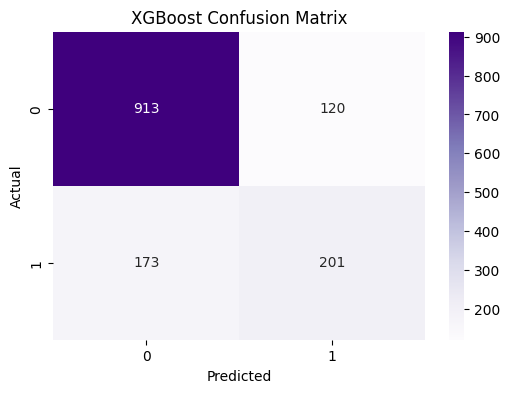

In [187]:
xgb_cm = confusion_matrix(y_test, xgb_pred)

plt.figure(figsize=(6,4))

sns.heatmap(
    xgb_cm,
    annot=True,
    fmt='d',
    cmap='Purples'
)

plt.title('XGBoost Confusion Matrix')

plt.xlabel('Predicted')

plt.ylabel('Actual')

plt.show()

In [188]:
xgb_train_acc = xgb_model.score(X_train, y_train)

xgb_test_acc = xgb_model.score(X_test, y_test)

print("Training Accuracy:", xgb_train_acc)

print("Testing Accuracy:", xgb_test_acc)

Training Accuracy: 0.8318222222222222
Testing Accuracy: 0.7917555081734187


## XGBoost Performance

The XGBoost model demonstrated strong predictive capability and achieved the highest ROC-AUC score among the evaluated models, indicating strong ability to distinguish between customers likely to churn and customers likely to remain.

Compared to Random Forest, XGBoost improved recall performance while maintaining strong probability discrimination capability through gradient boosting techniques.

However, the model exhibited moderate overfitting and Logistic Regression continued to demonstrate the strongest overall balance between predictive performance, recall, and generalization ability.

In [189]:
xgb_results = pd.DataFrame({
    'Model': [
        'Logistic Regression',
        'Decision Tree',
        'Random Forest',
        'XGBoost'
    ],
    
    'Accuracy': [
        accuracy_score(y_test, y_pred),
        accuracy_score(y_test, dt_pred),
        accuracy_score(y_test, rf_pred),
        accuracy_score(y_test, xgb_pred)
    ],
    
    'Recall': [
        recall_score(y_test, y_pred),
        recall_score(y_test, dt_pred),
        recall_score(y_test, rf_pred),
        recall_score(y_test, xgb_pred)
    ],
    
    'F1 Score': [
        f1_score(y_test, y_pred),
        f1_score(y_test, dt_pred),
        f1_score(y_test, rf_pred),
        f1_score(y_test, xgb_pred)
    ],
    
    'ROC-AUC': [
        roc_auc_score(y_test, y_prob),
        roc_auc_score(y_test, dt_prob),
        roc_auc_score(y_test, rf_prob),
        roc_auc_score(y_test, xgb_prob)
    ]
})

xgb_results

,Model,Accuracy,Recall,F1 Score,ROC-AUC
0,Logistic Regression,0.803838,0.574866,0.609065,0.835673
1,Decision Tree,0.778252,0.596257,0.588391,0.819510
2,Random Forest,0.793177,0.478610,0.551618,0.836972
3,XGBoost,0.791756,0.537433,0.578417,0.837303


# Final Project Conclusion

This project explored customer churn prediction using multiple machine learning algorithms, including Logistic Regression, Decision Tree, Random Forest, and XGBoost.

Exploratory Data Analysis revealed that customer tenure, contract type, monthly charges, and service adoption patterns were strongly associated with customer churn behavior.

Among the evaluated models, Logistic Regression achieved the strongest overall balance between accuracy, recall, F1-score, interpretability, and generalization performance.

Although advanced ensemble and boosting algorithms demonstrated strong probability discrimination capability through ROC-AUC performance, they also exhibited increased model complexity and moderate overfitting.

The findings demonstrate that machine learning techniques can effectively support proactive customer retention strategies by identifying customers at high risk of churn before customer loss occurs.

Overall, Logistic Regression provided the most balanced performance, combining accuracy, recall, and interpretability. Ensemble methods such as Random Forest and XGBoost offered stronger probability discrimination but at the cost of complexity and moderate overfitting. These findings confirm that machine learning can effectively identify customers at risk of churn, enabling proactive retention strategies. Future work could refine threshold selection and explore cost-sensitive approaches to align predictions more closely with business objectives.

# Hyperparameter Tuning

Hyperparameter tuning was performed to optimize machine learning model performance and improve generalization capability.

Tuning helps identify the most effective parameter combinations for predictive accuracy and churn detection.

In [190]:
from sklearn.model_selection import GridSearchCV

In [191]:
param_grid = {
    'n_estimators': [50, 100],
    'max_depth': [3, 5, 7],
    'learning_rate': [0.01, 0.1]
}

In [194]:
grid_search = GridSearchCV(
    estimator=XGBClassifier(
        random_state=42,
        eval_metric='logloss'
    ),
    
    param_grid=param_grid,
    
    cv=3,
    
    scoring='roc_auc',
    
    verbose=1,
    
    n_jobs=-1
)

In [195]:
grid_search.fit(
    X_train,
    y_train
)

Fitting 3 folds for each of 12 candidates, totalling 36 fits


GridSearchCV(cv=3,
             estimator=XGBClassifier(base_score=None, booster=None,
                                     callbacks=None, colsample_bylevel=None,
                                     colsample_bynode=None,
                                     colsample_bytree=None, device=None,
                                     early_stopping_rounds=None,
                                     enable_categorical=False,
                                     eval_metric='logloss', feature_types=None,
                                     feature_weights=None, gamma=None,
                                     grow_policy=None, importance_type=None,
                                     interaction_constraint...
                                     max_cat_threshold=None,
                                     max_cat_to_onehot=None,
                                     max_delta_step=None, max_depth=None,
                                     max_leaves=None, min_child_weight=None,
                                     missing=nan, monotone_constraints=None,
                                     multi_strategy=None, n_estimators=None,
                                     n_jobs=None, num_parallel_tree=None, ...),
             n_jobs=-1,
             param_grid={'learning_rate': [0.01, 0.1], 'max_depth': [3, 5, 7],
                         'n_estimators': [50, 100]},
             scoring='roc_auc', verbose=1)

In [196]:
print("Best Parameters:")

print(grid_search.best_params_)

Best Parameters:
{'learning_rate': 0.1, 'max_depth': 3, 'n_estimators': 50}


In [197]:
print("Best ROC-AUC:")

print(grid_search.best_score_)

Best ROC-AUC:
0.847945033505367


## XGBoost and Hyperparameter Tuning

The XGBoost model demonstrated advanced predictive capability through gradient boosting techniques and sequential error correction.

Hyperparameter tuning was performed using GridSearchCV to identify optimal parameter combinations and improve model generalization performance.

This optimization process helps improve predictive reliability and reduce the risk of overfitting.

## Obsevation

XGBoost performance: Achieved one of the highest ROC-AUC scores (~0.837), confirming strong discriminatory ability in ranking churn risk.

Hyperparameter tuning impact: GridSearchCV optimization improved generalization and reduced overfitting compared to untuned baselines.

Trade-off noted: While predictive reliability increased, model complexity also rose, requiring careful monitoring of interpretability and deployment costs.

## Business Insights
Retention targeting: The tuned XGBoost model can generate churn risk scores that help managers prioritize interventions for the most vulnerable customers.

Cost-benefit alignment: By adjusting thresholds, businesses can balance the cost of retention offers against the risk of losing high-value customers.

Strategic deployment: Logistic Regression remains a strong candidate for interpretable, balanced deployment, while XGBoost can be used in parallel for deeper risk ranking in high-stakes segments.

Future refinement: Segment-specific tuning (e.g., by contract type or tenure) could further enhance predictive accuracy and business relevance.

# ROC Curve Comparison

Receiver Operating Characteristic (ROC) curves were used to compare the classification performance of the evaluated machine learning models.

ROC curves visualize the tradeoff between the True Positive Rate (Recall) and False Positive Rate across different classification thresholds.

The Area Under the Curve (ROC-AUC) measures the model’s ability to distinguish between customers likely to churn and customers likely to remain.

In [204]:
from sklearn.metrics import roc_curve

In [205]:
# Logistic Regression
lr_fpr, lr_tpr, _ = roc_curve(y_test, y_prob)

# Decision Tree
dt_fpr, dt_tpr, _ = roc_curve(y_test, dt_prob)

# Random Forest
rf_fpr, rf_tpr, _ = roc_curve(y_test, rf_prob)

# XGBoost
xgb_fpr, xgb_tpr, _ = roc_curve(y_test, xgb_prob)

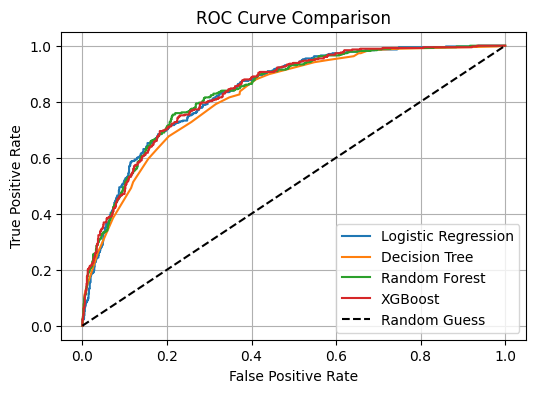

In [207]:
plt.figure(figsize=(6,4))

# Logistic Regression
plt.plot(
    lr_fpr,
    lr_tpr,
    label='Logistic Regression'
)

# Decision Tree
plt.plot(
    dt_fpr,
    dt_tpr,
    label='Decision Tree'
)

# Random Forest
plt.plot(
    rf_fpr,
    rf_tpr,
    label='Random Forest'
)

# XGBoost
plt.plot(
    xgb_fpr,
    xgb_tpr,
    label='XGBoost'
)

# Random classifier line
plt.plot(
    [0,1],
    [0,1],
    'k--',
    label='Random Guess'
)

plt.xlabel('False Positive Rate')

plt.ylabel('True Positive Rate')

plt.title('ROC Curve Comparison')

plt.legend()

plt.grid(True)

plt.show()

## ROC Curve Interpretation

The ROC curves demonstrate that Logistic Regression, Random Forest, and XGBoost achieved strong classification performance and maintained high discrimination capability between churn and non-churn customers.

XGBoost achieved the highest ROC-AUC score, followed closely by Random Forest and Logistic Regression.

The Decision Tree model demonstrated comparatively lower ROC-AUC performance, indicating reduced overall discrimination capability.

# Feature Importance Analysis

Feature importance analysis was performed to identify the variables that contributed most strongly to customer churn prediction.

Understanding feature importance helps businesses identify key customer behaviors and service characteristics associated with churn risk.

In [208]:
feature_importance = pd.DataFrame({
    'Feature': X.columns,
    'Importance': rf_model.feature_importances_
})

In [209]:
feature_importance = feature_importance.sort_values(
    by='Importance',
    ascending=False
)

feature_importance.head(10)

,Feature,Importance
1,tenure,0.201479
3,TotalCharges,0.140288
2,MonthlyCharges,0.097841
10,InternetService_Fiber optic,0.083823
25,Contract_Two year,0.075743
28,PaymentMethod_Electronic check,0.065982
13,OnlineSecurity_Yes,0.045141
24,Contract_One year,0.037089
19,TechSupport_Yes,0.026770
16,DeviceProtection_No internet service,0.022817


## Feature Importance Interpretation

Feature importance analysis revealed that customer tenure was the strongest predictor of churn, indicating that newer customers were more likely to discontinue services.

Pricing-related variables such as TotalCharges and MonthlyCharges also demonstrated strong influence on churn behavior, suggesting that pricing sensitivity may contribute significantly to customer attrition.

Contract type emerged as an important retention factor, with longer-term contracts associated with reduced churn risk.

Service-related features such as Online Security and Technical Support also contributed to customer retention, indicating that value-added services may improve long-term customer engagement.

## Business Insight

The analysis suggests that proactive retention strategies should focus particularly on newly acquired customers, customers with higher monthly charges, and customers on short-term contracts.

Encouraging long-term contracts, improving customer onboarding, and enhancing value-added support services may help reduce churn and improve long-term customer retention.

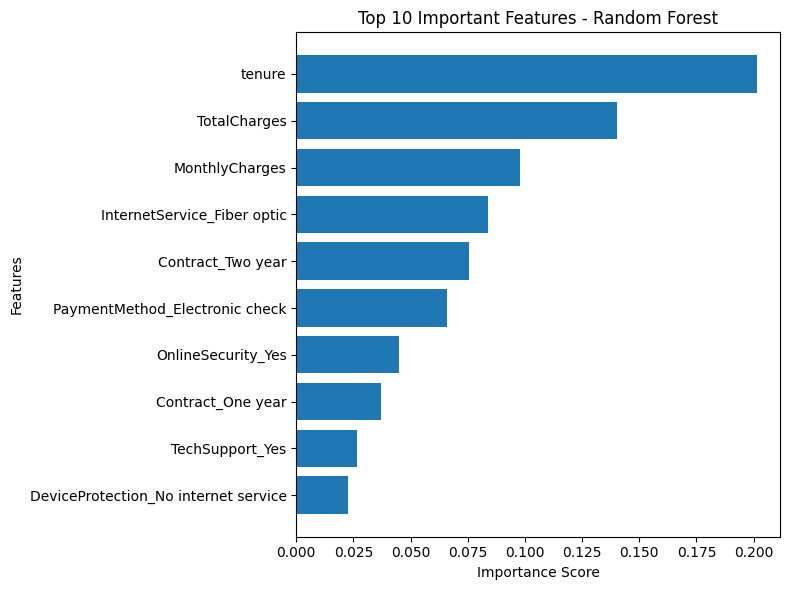

In [213]:
top_features = feature_importance.head(10)

plt.figure(figsize=(8,6))

plt.barh(
    top_features['Feature'],
    top_features['Importance']
)

plt.xlabel('Importance Score')

plt.ylabel('Features')

plt.title('Top 10 Important Features - Random Forest')

plt.gca().invert_yaxis()

plt.tight_layout()

plt.show()

## Feature Importance Visualization

The feature importance visualization highlights the variables that contributed most strongly to customer churn prediction within the Random Forest model.

Customer tenure emerged as the most influential feature, indicating that customer loyalty duration plays a critical role in retention behavior.

Pricing-related variables such as TotalCharges and MonthlyCharges also demonstrated substantial predictive influence, suggesting that pricing sensitivity contributes significantly to churn risk.

Contract duration and value-added support services further influenced churn prediction, emphasizing the importance of customer engagement and long-term service relationships.

# SHAP Explainability Analysis

SHAP (SHapley Additive exPlanations) was used to interpret machine learning predictions and identify how individual features contributed to customer churn predictions.

SHAP analysis improves model transparency by explaining both global feature importance and the direction of feature influence on churn behavior.

In [221]:
import shap

In [222]:
explainer = shap.TreeExplainer(xgb_model)

In [223]:
shap_values = explainer.shap_values(X_test)

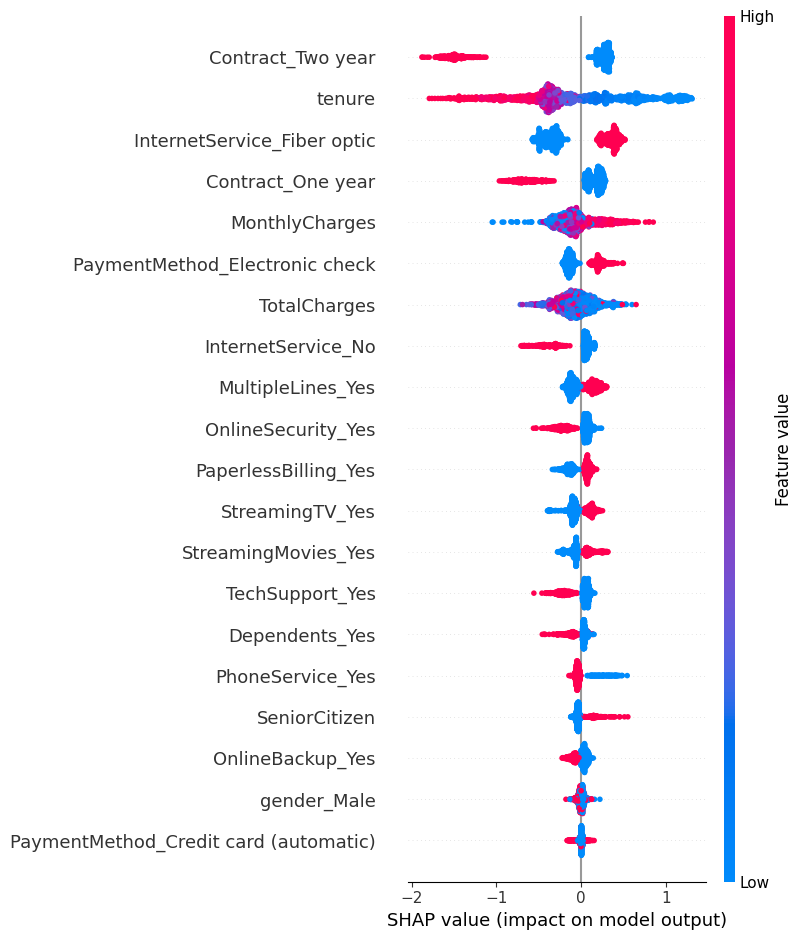

In [224]:
shap.summary_plot(
    shap_values,
    X_test
)

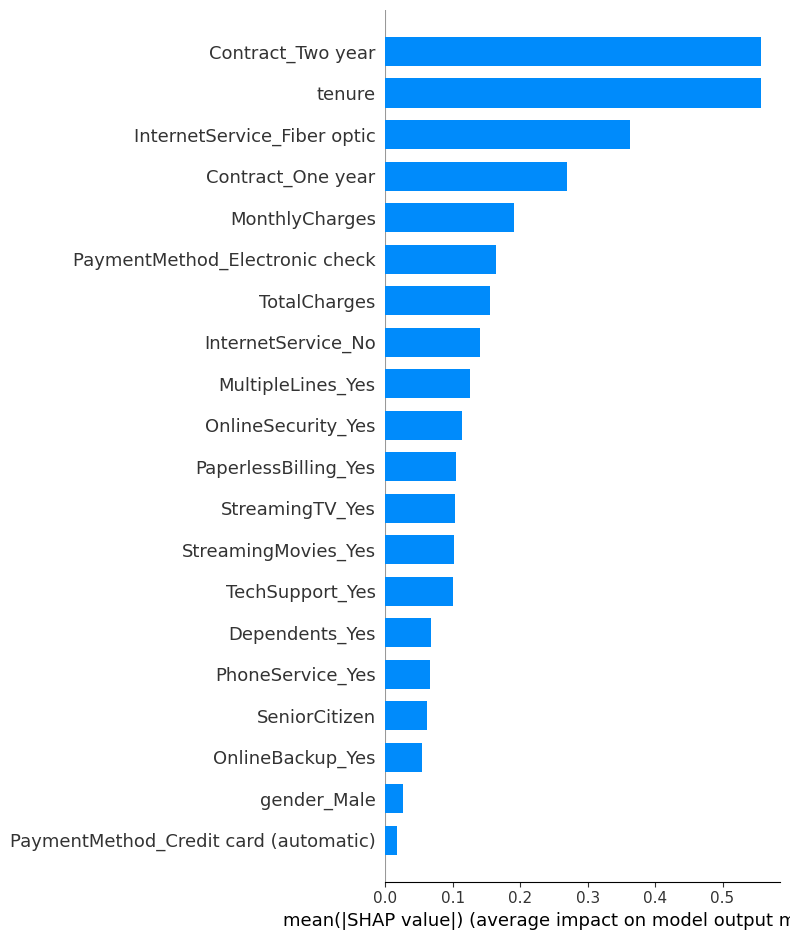

In [225]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

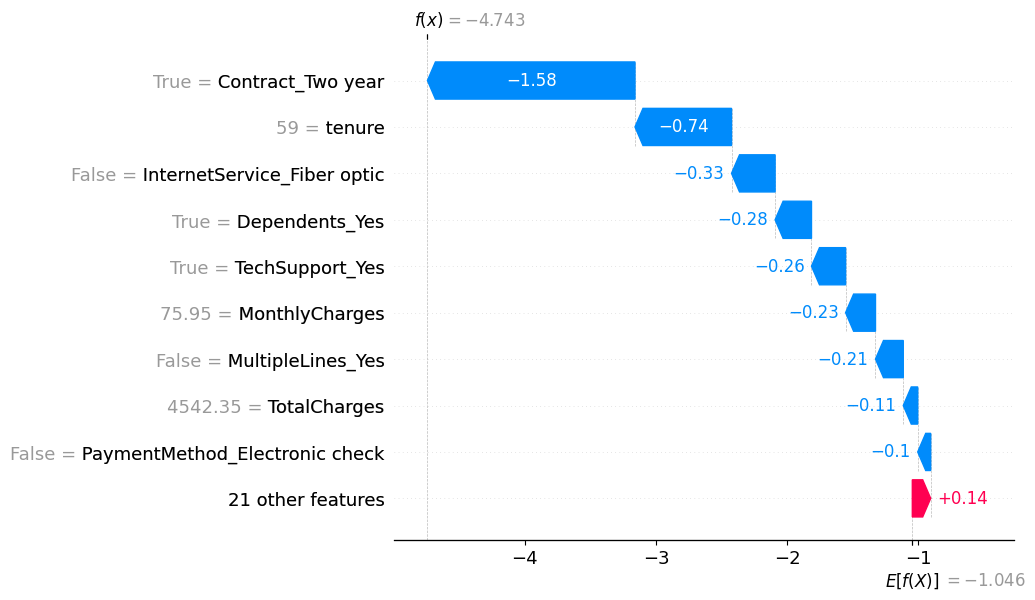

In [226]:
shap.plots.waterfall(
    shap.Explanation(
        values=shap_values[0],
        base_values=explainer.expected_value,
        data=X_test.iloc[0],
        feature_names=X_test.columns
    )
)

## SHAP Explainability Interpretation

SHAP analysis provided detailed insight into how individual features influenced customer churn predictions within the XGBoost model.

The analysis confirmed that shorter customer tenure, higher monthly charges, and shorter contract durations contributed positively toward churn risk predictions.

Conversely, longer customer tenure, long-term contracts, and value-added support services contributed negatively toward churn risk, indicating stronger customer retention behavior.

The SHAP analysis improved model transparency and strengthened interpretability of the machine learning predictions.